In [5]:
import subprocess
import os
import logging
import numpy as np

from stgeorges_utils_mod import change_ismrmrd, to_dicom_folder, LogfileCallback

from sirf.Gadgetron import AcquisitionData, ImageData
from sirf.Gadgetron import AcquisitionModel
from sirf.Gadgetron import AcquisitionDataProcessor
from sirf.Gadgetron import CartesianGRAPPAReconstructor, FullySampledReconstructor
from sirf.Gadgetron import CoilSensitivityData
from sirf.Gadgetron import preprocess_acquisition_data

from cil.optimisation.functions import LeastSquares
from cil.optimisation.functions import ZeroFunction
from cil.optimisation.algorithms import FISTA, CGLS, GD
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.framework import DataContainer as cilDataContainer
from cil.optimisation.operators import LinearOperator
from cil.optimisation.utilities.callbacks import ProgressCallback, TextProgressCallback
import tempfile
from numbers import Number

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

command = "siemens_to_ismrmrd"
# data_dir = "/home/jovyan/work/data/"
data_dir = os.path.abspath('/input')
# proc_dir = os.path.join(data_dir, "proc")
proc_dir = tempfile.mkdtemp(prefix="stgeorges_proc_")
# recon_dir = os.path.join(data_dir, "recon")
recon_dir = os.path.abspath('/output')

which = 1
all_input_files = [            
                "meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL.dat",
                "meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL.dat", # patient1 AI dataset
                "meas_MID00807_FID335377_pd_tse_fs_sag_320.dat", #patient3 sagittal
                "meas_MID00815_FID335385_pd_tse_fs_cor_p2_s2_448.dat" #patient3 coronal GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.
]

Ls = [None, 
      None, 
      7.653403327994994, 
      1.9333921944843908]

if isinstance(which, Number):
    input_files = [ all_input_files[which] ]
    L = Ls[which]
else:
    raise ValueError('Please select which dataset to reconstruct by setting which to a number')
    
mod_input_files = []
for fname in input_files:
    logger.info(f"Processing file {fname}...")
    file_in = os.path.join(data_dir, fname)
    file_out = os.path.join(proc_dir, os.path.basename(file_in).replace(".dat", ".h5"))
    if os.path.exists(file_out):
        logger.warning(f"Output file {file_out} already exists. Removing it.")
        os.remove(file_out)
    
    # siemens_to_ismrmrd -f meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL.dat -o meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL.h5 -Z -M
    # https://discord.com/channels/1242028164105109574/1481253905852792962/1481263393733087345

    out = subprocess.run(
        [command, "-f", file_in, "-o", file_out, "-z", "2", "-M"],
        capture_output=True,
        text=True,
    )

    logger.info(out.stdout)
    logger.error(out.stderr)

    # Change ISMRMRD file if needed
    file_out_mod = file_out.replace(".h5", "_mod.h5")
    change_ismrmrd(file_out, file_out_mod)
    logger.info(f"Modified ISMRMRD file saved as {file_out_mod}")
    mod_input_files.append(file_out_mod)

# reconstruct AI recon

INFO:__main__:Processing file meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL.dat...
INFO:__main__:Siemens file is: /input/meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL.dat
-----------------------------------------------------------------
Converting measurement 2 into file /tmp/stgeorges_proc_zumqees0/meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL.h5 in group dataset
-----------------------------------------------------------------
Using parameter map: IsmrmrdParameterMap_Siemens.xml
This file contains 2 measurement(s).
VD line file detected.
Protocol name [1]: AdjCoilSens
Protocol name [2]: BOOST SEQD 512 UFLEXL no spine GF2 AX RL pd_tse_fs_sag
Number of parameter buffers: 7
Buffer Name: Config
Buffer Name: Dicom
Buffer Name: Meas
Buffer Name: MeasYaps
Buffer Name: Phoenix
Buffer Name: Protocol
Buffer Name: Spice
Trajectory is: 1
Failed to find YAPS.lFirstFourierLine array
Failed to find YAPS.lFirstFourierPartition array
center_line = 256
center_partition = 0
Failed to 

In [6]:
for file in mod_input_files:
    pass
logger.info(f"Reconstructing file {file}...")

# downsampled data
acq_data_ai = AcquisitionData(file)
acq_data_ai = preprocess_acquisition_data(acq_data_ai)

csm = CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data_ai)
logger.info(f"CSM done")

E = AcquisitionModel(acqs=acq_data_ai, imgs=csm)
E.set_coil_sensitivity_maps(csm)
logger.info(f"Created E")
# Use the result of the inverse as our starting point
# logger.info(f"Creating inverse")
inverse = E.inverse(acq_data_ai)
x_init = inverse * 0 
logger.info(f"Created inverse")

INFO:__main__:Reconstructing file /tmp/stgeorges_proc_zumqees0/meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5...


ed it to be constant.

GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.

GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.

GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.

GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.

GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.

GadgetronImagesVector::set_up_geom_info(): Slice distances alters between slices. Expected it to be constant.
reading from /tmp/stgeorges_proc_zumqees0/meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /tmp/stgeorges_proc_zumqees0/meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX

INFO:__main__:CSM done
INFO:__main__:Created E
INFO:__main__:Created inverse


(np.int32(18), np.int32(512), np.int32(512))


/opt/conda/lib/python3.12/site-packages/cil/utilities/display.py:684: PendingDeprecationWarning: The set_tight_layout function will be deprecated in a future version. Use set_layout_engine instead.
  fig.set_tight_layout(True)


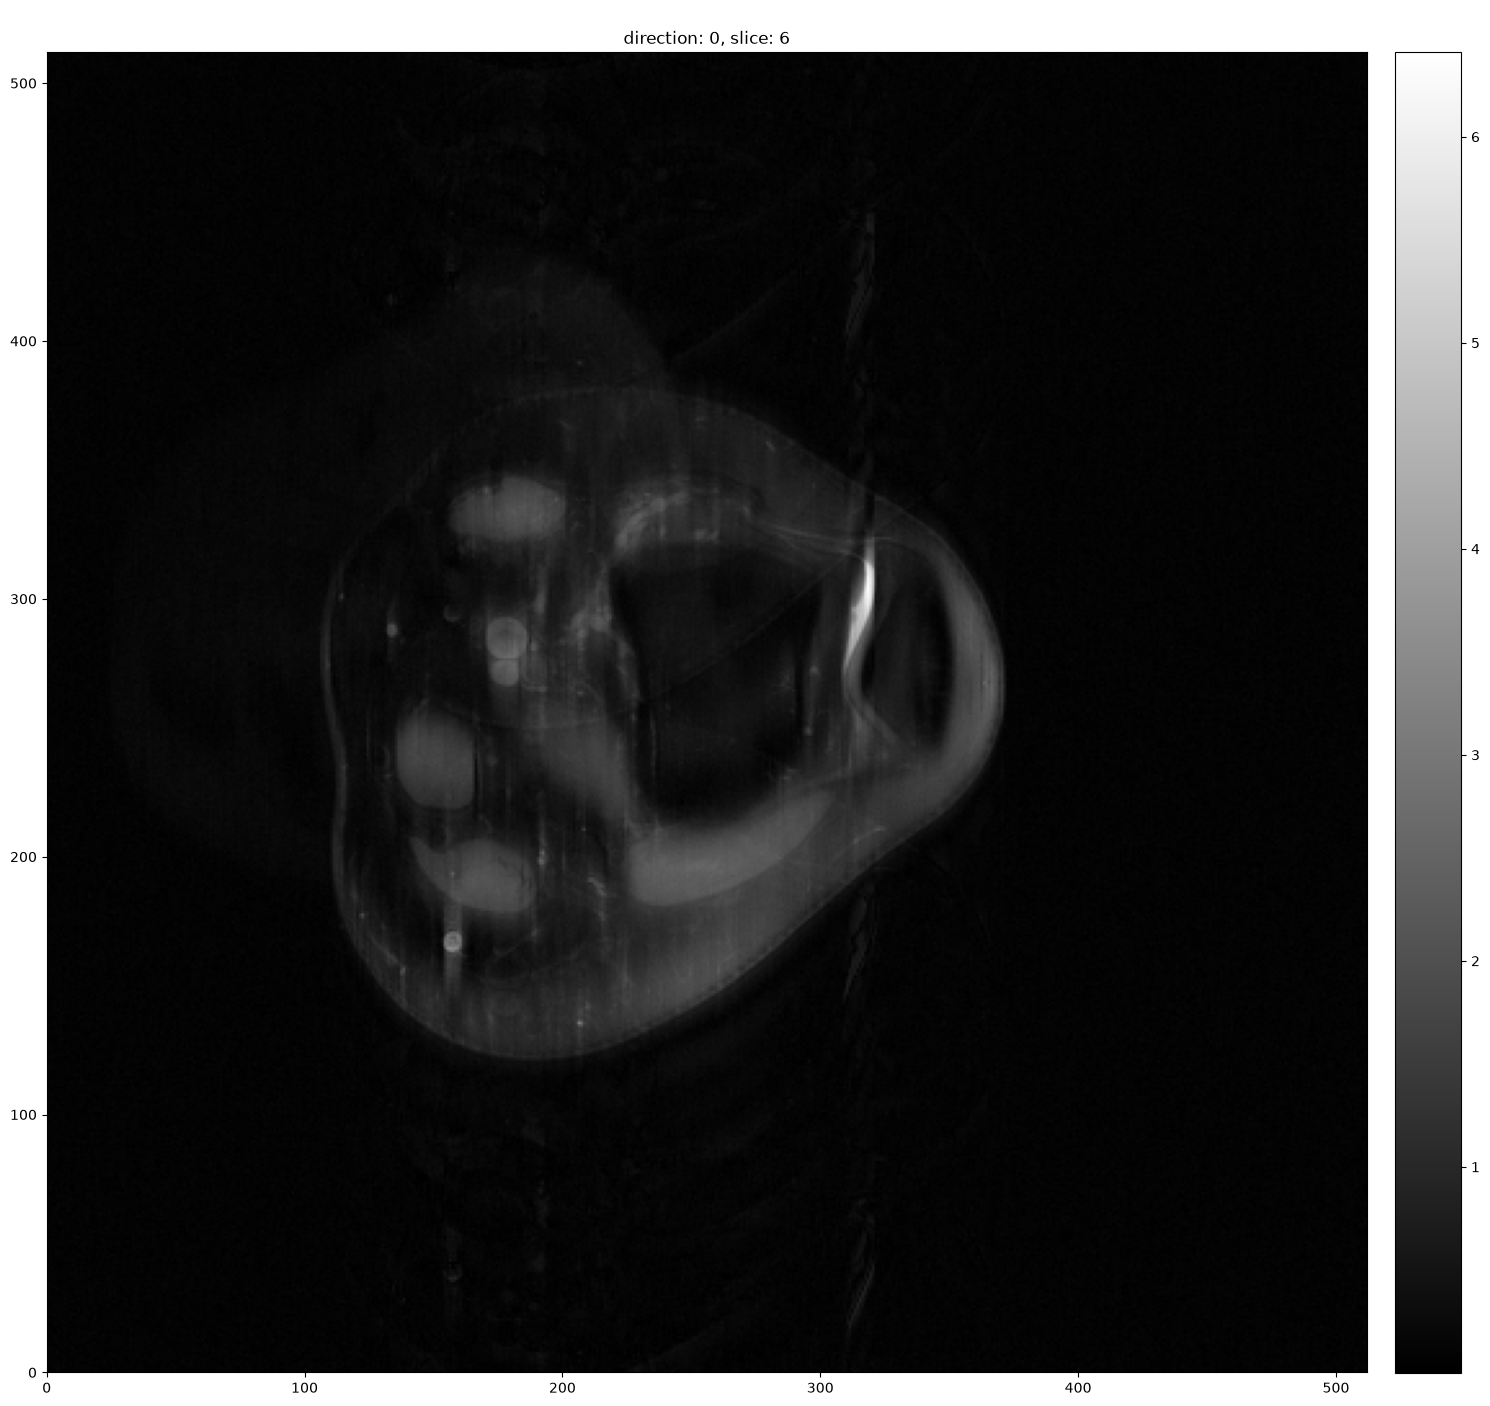

In [8]:
from cil.utilities.display import show2D
print(x_init.shape)
show2D(np.abs(inverse.asarray()), slice_list=(0,6))

In [35]:
from cil.optimisation.utilities.callbacks import Callback

class SaveIteratesCallback(Callback):
    def __init__(self, save_interval=1):
        self.iterates = []
        self.iter_num = []
        self.save_interval = save_interval
    def __call__(self, algorithm):
        if algorithm.iteration % self.save_interval == 0:
            self.iterates.append(algorithm.solution.copy())
            self.iter_num.append(algorithm.iteration)
        

In [36]:
# We set up our AcquisitionModel
E = AcquisitionModel(acqs=acq_data_ai, imgs=x_init)
E.set_coil_sensitivity_maps(csm)

# Define our objective/loss function as least squares between Ex and y
f = LeastSquares(E, acq_data_ai, c=1)
L = 8.987434373466499
if L is not None:
    f.L = L

alpha = 0.3
TV = FGP_TV(alpha=alpha, nonnegativity=False, device='cpu')
G = TV

# add logger callback to FISTA


# Set up FISTA
fista = FISTA(initial=x_init.fill(0.0), f=f, g=G)
fista.update_objective_interval = 1
callback = SaveIteratesCallback()
from cil.optimisation.utilities.callbacks import ProgressCallback

# Run FISTA for least squares
num_iterations = 10
fista.run(num_iterations, callbacks=[callback, ProgressCallback()])

/opt/conda/lib/python3.12/site-packages/cil/optimisation/functions/LeastSquares.py:113: UserWarning: You should set the Lipschitz constant with calculate_Lipschitz().
  warnings.warn("You should set the Lipschitz constant with calculate_Lipschitz().")
INFO:cil.optimisation.algorithms.FISTA:FISTA setting up
INFO:cil.optimisation.algorithms.FISTA:FISTA configured
/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:129: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')


  0%|          | 0/10 [00:00<?, ?it/s]

/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:129: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:129: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:129: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:129: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
/opt/conda/lib/python3.12/si

In [33]:
f.L

np.float64(8.987434373466499)

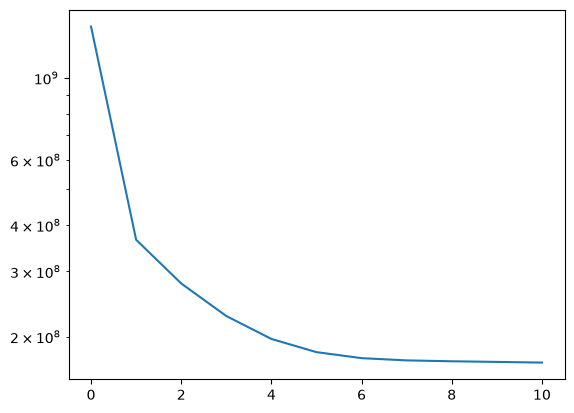

In [10]:
import matplotlib.pyplot as plt
plt.semilogy(fista.loss)

In [15]:
sols[0].shape

(np.int32(18), np.int32(512), np.int32(512))

/opt/conda/lib/python3.12/site-packages/cil/utilities/display.py:684: PendingDeprecationWarning: The set_tight_layout function will be deprecated in a future version. Use set_layout_engine instead.
  fig.set_tight_layout(True)


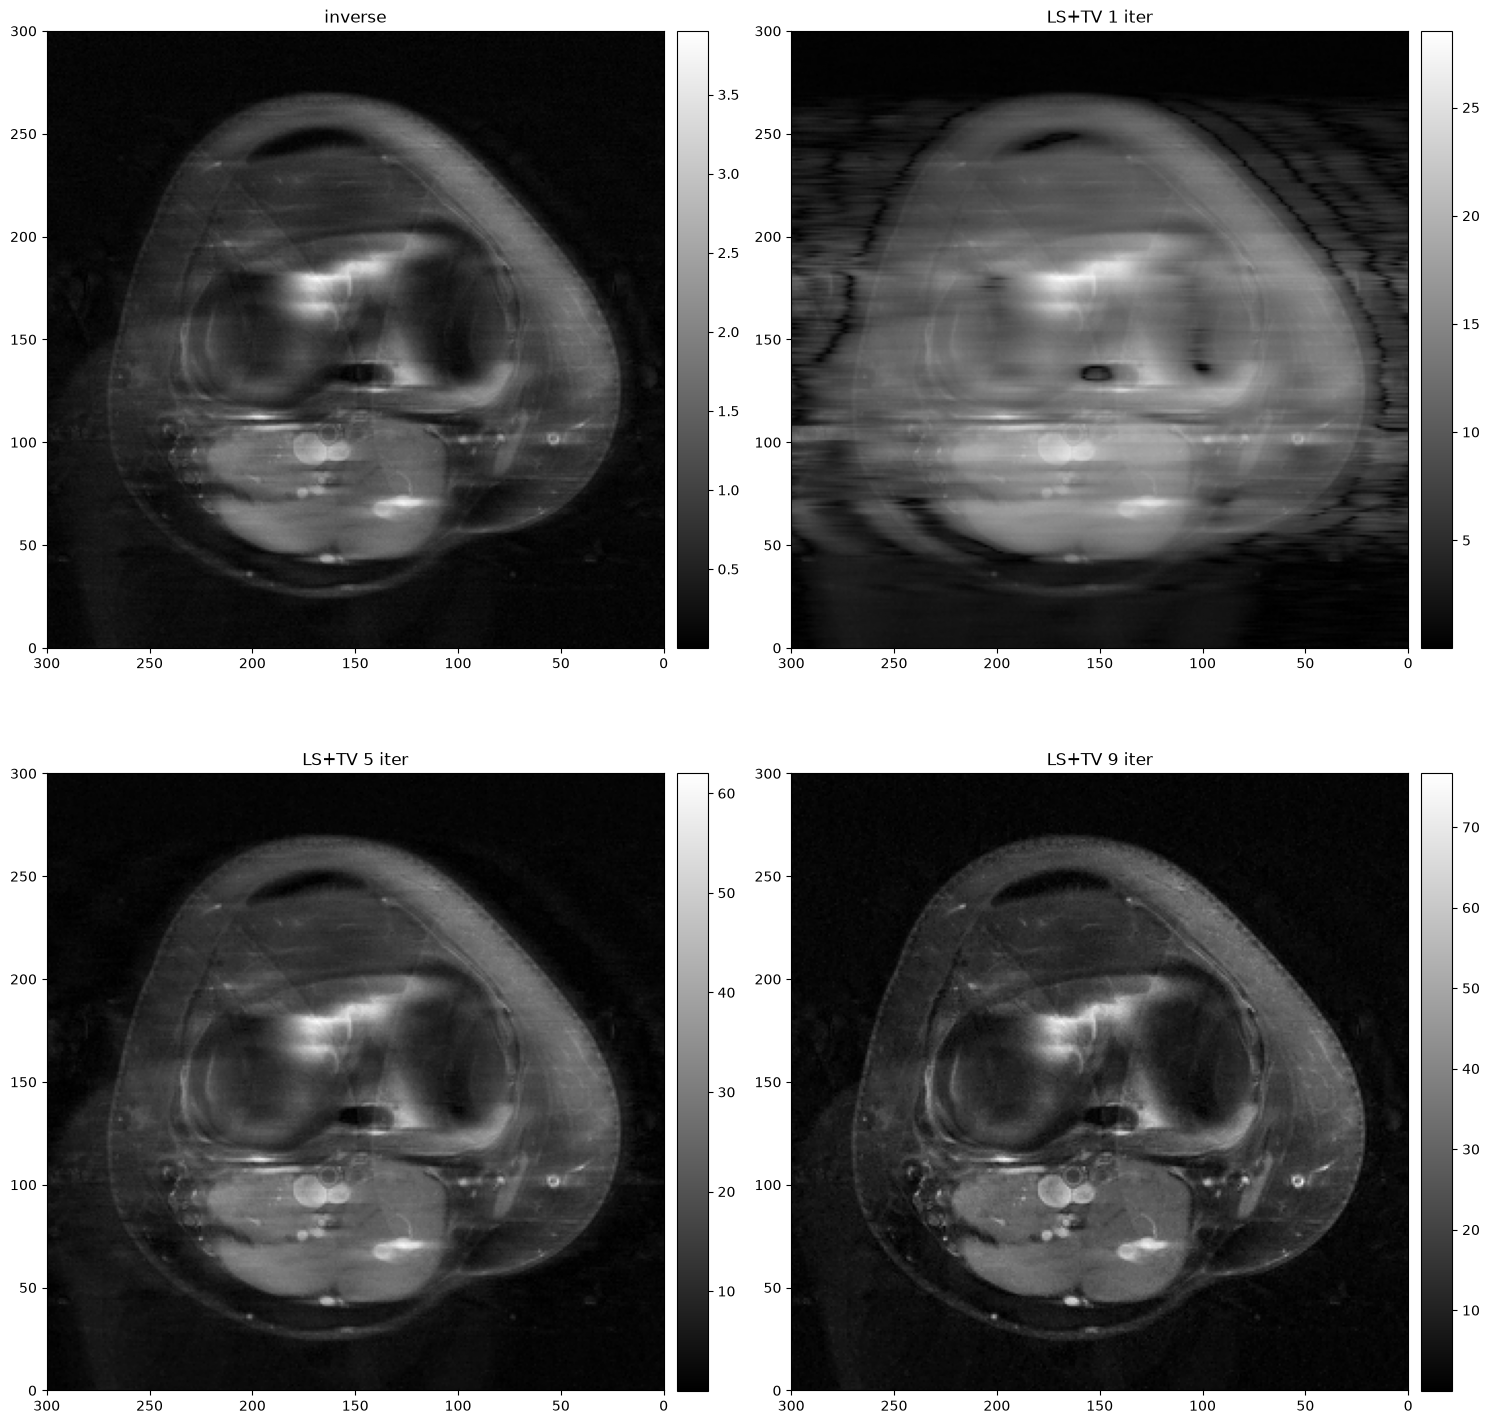

8.987434373466499


In [37]:
from cil.utilities.display import show2D
sols = callback.iterates
# from cil.utilities.jupyter import islicer
show2D([np.squeeze(np.abs(el.asarray()[11,110:410, 80:380])).T for el in [inverse, *[sols[el] for el in [1,5,9]]]], 
       # slice_list=(0,11), 
       title=['inverse', *[f'LS+TV {el} iter' for el in [1,5,9]]], 
       origin='lower-right'
      )
# islicer(np.abs(fista.solution.asarray()))
print (f.L)

In [ ]:
to_dicom_folder(
    data=fista.solution, 
    foldername=recon_dir, 
    filename_prefix="sirf_recon_" + os.path.basename(file).replace(".h5", ""),
    series_description=f"SIRF recon_{num_iterations} LS+ {alpha} TV"
)

In [ ]:
# delete proc_dir
if os.path.exists(proc_dir):
    logger.info(f"Deleting temporary processing directory {proc_dir}...")
    try:
        for fname in os.listdir(proc_dir):
            os.remove(os.path.join(proc_dir, fname))
        os.rmdir(proc_dir)
        logger.info("Temporary processing directory deleted successfully.")
    except Exception as e:
        logger.error(f"Error deleting temporary processing directory: {e}")

In [ ]:

pixel_data = inverse.abs()
pixel_data = pixel_data / pixel_data.max() * (2**16 - 1)
# pixel_data = np.swapaxes(pixel_data, -1, -2)


In [ ]:
import sirf.Reg as reg

# save to temporary nifti file
type(pixel_data)
nim = reg.NiftiImageData3D(pixel_data)